In [ ]:
import pandas as pd

In [ ]:
path = '/content/IBM.csv'

af = pd.read_csv(path)

In [ ]:
af.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


In [ ]:
af.dtypes

,0
Age,int64
Attrition,object
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
JobSatisfaction,int64
MaritalStatus,object
MonthlyIncome,int64


In [ ]:
af.shape

(1470, 13)

In [ ]:
af.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
WorkLifeBalance,1470.0,2.761224,0.706476,1.0,2.0,3.0,3.0,4.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0


In [ ]:
print("--- Value Counts ---")
print(af["Attrition"].value_counts())


print("\n--- Proportions ---")
print(af["Attrition"].value_counts(normalize=True) * 100)

--- Value Counts ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

--- Proportions ---
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


/tmp/ipykernel_852/1114996441.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  seaborn_plt.boxplot(


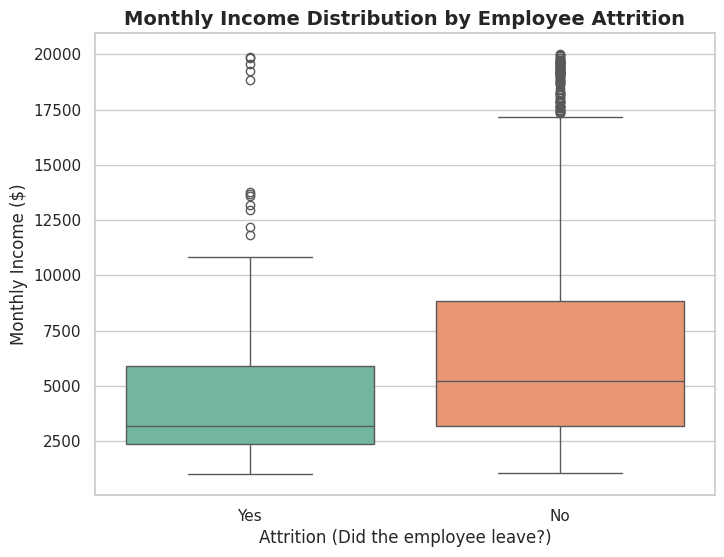

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as seaborn_plt

seaborn_plt.set_theme(style="whitegrid")


plt.figure(figsize=(8, 6))

seaborn_plt.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=af,
    palette="Set2"
)

plt.title("Monthly Income Distribution by Employee Attrition", fontsize=14, fontweight="bold")
plt.xlabel("Attrition (Did the employee leave?)", fontsize=12)
plt.ylabel("Monthly Income ($)", fontsize=12)


plt.show()

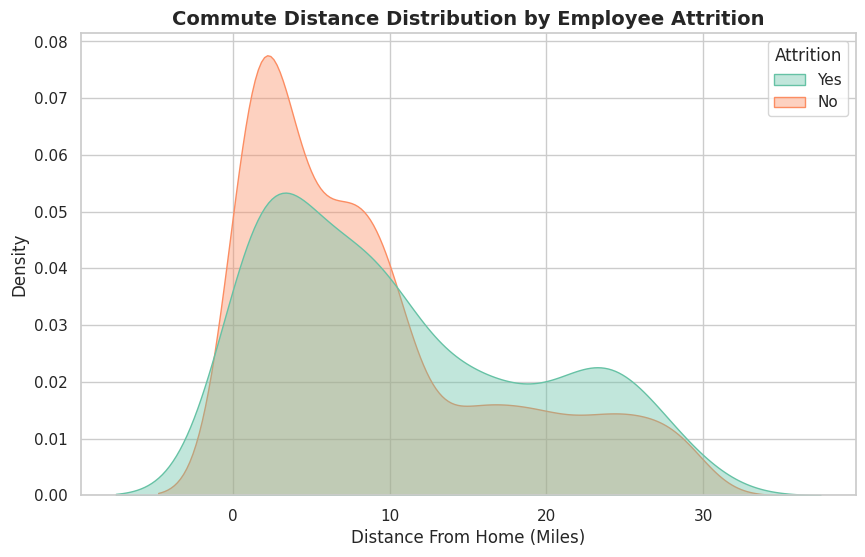

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=af,
    x="DistanceFromHome",
    hue="Attrition",
    common_norm=False,
    fill=True,
    palette="Set2",
    alpha=0.4
)


plt.title("Commute Distance Distribution by Employee Attrition", fontsize=14, fontweight="bold")
plt.xlabel("Distance From Home (Miles)", fontsize=12)
plt.ylabel("Density", fontsize=12)


plt.show()

/tmp/ipykernel_852/977276650.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_852/977276650.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


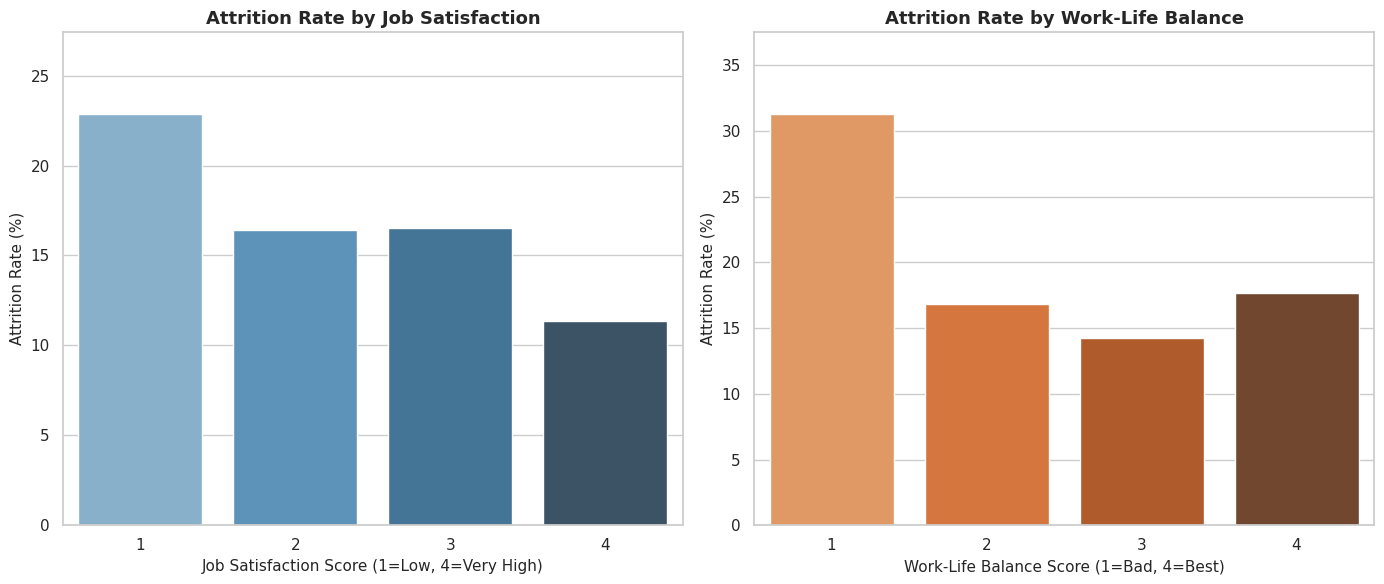

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

js_attrition = (
    af.groupby('JobSatisfaction')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='AttritionPercentage')
)

sns.barplot(
    data=js_attrition,
    x='JobSatisfaction',
    y='AttritionPercentage',
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title("Attrition Rate by Job Satisfaction", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Job Satisfaction Score (1=Low, 4=Very High)", fontsize=11)
axes[0].set_ylabel("Attrition Rate (%)", fontsize=11)
axes[0].set_ylim(0, max(js_attrition['AttritionPercentage']) * 1.2)


wlb_attrition = (
    af.groupby('WorkLifeBalance')['Attrition']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index(name='AttritionPercentage')
)

sns.barplot(
    data=wlb_attrition,
    x='WorkLifeBalance',
    y='AttritionPercentage',
    ax=axes[1],
    palette='Oranges_d'
)
axes[1].set_title("Attrition Rate by Work-Life Balance", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Work-Life Balance Score (1=Bad, 4=Best)", fontsize=11)
axes[1].set_ylabel("Attrition Rate (%)", fontsize=11)
axes[1].set_ylim(0, max(wlb_attrition['AttritionPercentage']) * 1.2)


plt.tight_layout()
plt.show()

In [ ]:
af['Attrition'] = af['Attrition'].map({'Yes': 1, 'No': 0})

In [ ]:
af.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,1,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
1,49,0,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
2,37,1,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
3,33,0,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
4,27,0,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2


In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Department', 'EducationField', 'MaritalStatus']

le = LabelEncoder()

for col in categorical_cols:

    af[col] = le.fit_transform(af[col].astype(str))

print(af[categorical_cols].head())

   Department  EducationField  MaritalStatus
0           2               1              2
1           1               1              1
2           1               4              2
3           1               1              1
4           1               3              1


In [ ]:
af.head()

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
0,41,1,2,1,2,1,2,4,2,5993,8,1,6
1,49,0,1,8,1,1,3,2,1,5130,1,3,10
2,37,1,1,2,2,4,4,3,2,2090,6,3,0
3,33,0,1,3,4,1,4,3,1,2909,1,3,8
4,27,0,1,2,1,3,1,2,1,3468,9,3,2


In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['MonthlyIncome', 'Age', 'DistanceFromHome', 'YearsAtCompany', 'NumCompaniesWorked']


scaler = StandardScaler()


af[numerical_cols] = scaler.fit_transform(af[numerical_cols])

print(af[numerical_cols].head())

   MonthlyIncome       Age  DistanceFromHome  YearsAtCompany  \
0      -0.108350  0.446350         -1.010909       -0.164613   
1      -0.291719  1.322365         -0.147150        0.488508   
2      -0.937654  0.008343         -0.887515       -1.144294   
3      -0.763634 -0.429664         -0.764121        0.161947   
4      -0.644858 -1.086676         -0.887515       -0.817734   

   NumCompaniesWorked  
0            2.125136  
1           -0.678049  
2            1.324226  
3           -0.678049  
4            2.525591  


In [ ]:
# Logistic Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


cat_cols = ['Attrition', 'Department', 'EducationField', 'MaritalStatus']
le = LabelEncoder()
for col in cat_cols:
    af[col] = le.fit_transform(af[col])


X = af.drop(columns=['Attrition'])
y = af['Attrition']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_pred = log_reg.predict(X_test_scaled)


print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8435374149659864

Confusion Matrix:
 [[244   3]
 [ 43   4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294



In [ ]:
# Random Forest Classifier

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



cat_cols = ['Attrition', 'Department', 'EducationField', 'MaritalStatus']
le = LabelEncoder()
for col in cat_cols:
    af[col] = le.fit_transform(af[col])

X = af.drop(columns=['Attrition'])
y = af['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8367346938775511

Confusion Matrix:
 [[242   5]
 [ 43   4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
print("\nTop Features Driving Attrition:\n")
print(feature_importances.sort_values(ascending=False))


Top Features Driving Attrition:

MonthlyIncome              0.192790
Age                        0.148533
YearsAtCompany             0.118149
DistanceFromHome           0.110662
NumCompaniesWorked         0.080113
EnvironmentSatisfaction    0.060413
JobSatisfaction            0.053329
MaritalStatus              0.052718
Education                  0.052227
WorkLifeBalance            0.049612
EducationField             0.046855
Department                 0.034599
dtype: float64


In [ ]:
# Performance metrices

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
import matplotlib.pyplot as plt


y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

Precision: 0.44
Recall: 0.09
F1-Score: 0.14


ROC-AUC Score: 0.66


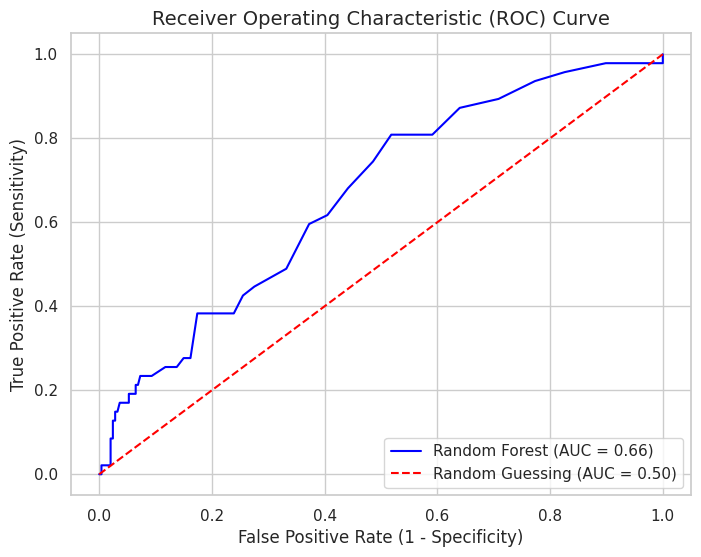

In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing (AUC = 0.50)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Load data
df = pd.read_csv('IBM.csv')

# Store LabelEncoders so we can map text back to numbers during prediction
cat_cols = ['Department', 'EducationField', 'MaritalStatus']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on the original text values
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Encode Attrition target
le_attrition = LabelEncoder()
df['Attrition'] = le_attrition.fit_transform(df['Attrition'])
encoders['Attrition'] = le_attrition

X = df.drop(columns=['Attrition'])
y = df['Attrition']

# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X, y)

# Save model and encoders using pickle
with open('attrition_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Model and encoders updated successfully with text categories!")

Model and encoders updated successfully with text categories!
